In [116]:
    # dependencies
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
import contact_model_plots as cmp
import contact_model_plots_pfc as cmppfc

In [117]:
# settings
bond_type = "pb"
experiment = 2
kn_ks = 1

In [118]:

# getting data
# Physics Sim
if bond_type == "cb":
    df = pd.read_csv(f"experiment_{experiment}_{kn_ks}.csv",delimiter=",")
else: 
    df = pd.read_csv(f"{bond_type}_experiment_{experiment}_{kn_ks}.csv",delimiter=",")
# df = pd.read_csv(f"Round_Walls!.csv",delimiter=",")
# df = df.iloc[1:]
# df = df.iloc[1:, :]
df = df.astype(float)
df["Timestamp"] = df["Timestamp"]  - df["Timestamp"][0]
# df = df[df["Timestamp"] > 0.0]
df["Timestamp"] = df["Timestamp"] - df.at[df.index[0], "Timestamp"]
# df["Timestamp"] = df["Timestamp"]  - df["Timestamp"][0]
# df["Timestamp"] = df["Timestamp"] - df["Timestamp"][0]
# df = df.drop(df.index[0])
# df2 = df.drop(df.index[0])&
# PFC
df2 = pd.read_fwf(f"histories/{bond_type}_experiment_{experiment}_{kn_ks}.his",delimiter=" ")
# df2 = pd.read_fwf(f"pb_experiment_{experiment}_{kn_ks}.his",delimiter=",")
df2 = df2.drop(df2.index[0])
df2 = df2.astype(float)
# df2["Timestamp"] = df2["Timestamp"]  - df2["Timestamp"][0]
df2.columns = ["Step", 
              "Time(s)", 
              "x_pos", 
              "y_pos", 
              "theta", 
              "x_vel", 
              "y_vel", 
              "omega", 
              "c_nforce", 
              "c_sforce", 
              "c_moment", 
              "c_normal_y_dir", 
              "c_normal_x_dir",
              "c_pos_y",
              "c_pos_x"]
df2 = df2[df2["Time(s)"] > 0.0005]
df2["Time(s)"] = df2["Time(s)"] - df2.at[df2.index[0], "Time(s)"]
print(df)
print(df2)

     Timestamp    X Position    Y Position    X Velocity  Y Velocity  \
0     0.000000  0.000000e+00  5.000000e-07  0.000000e+00    0.000000   
1     0.000000  0.000000e+00  5.000000e-07  0.000000e+00    0.000000   
2     0.000000  0.000000e+00  5.000000e-07  0.000000e+00    0.000000   
3     0.000000  0.000000e+00  5.000000e-07  0.000000e+00    0.000000   
4     0.000000  0.000000e+00  5.000000e-07  0.000000e+00    0.000000   
..         ...           ...           ...           ...         ...   
744   0.002485 -6.754000e-12  1.152022e-06 -2.441806e-08    0.000870   
745   0.002490 -6.873200e-12  1.156453e-06 -2.385755e-08    0.000886   
746   0.002495 -6.987600e-12  1.160974e-06 -2.287603e-08    0.000904   
747   0.002500 -7.095200e-12  1.165587e-06 -2.151111e-08    0.000923   
748   0.002505 -7.194200e-12  1.170297e-06 -1.981296e-08    0.000942   

     Rotation  Rotation Velocity     Data1      Data2     Data3  Data4  \
0    0.000000           0.000000  0.000000   0.000000  0.0000

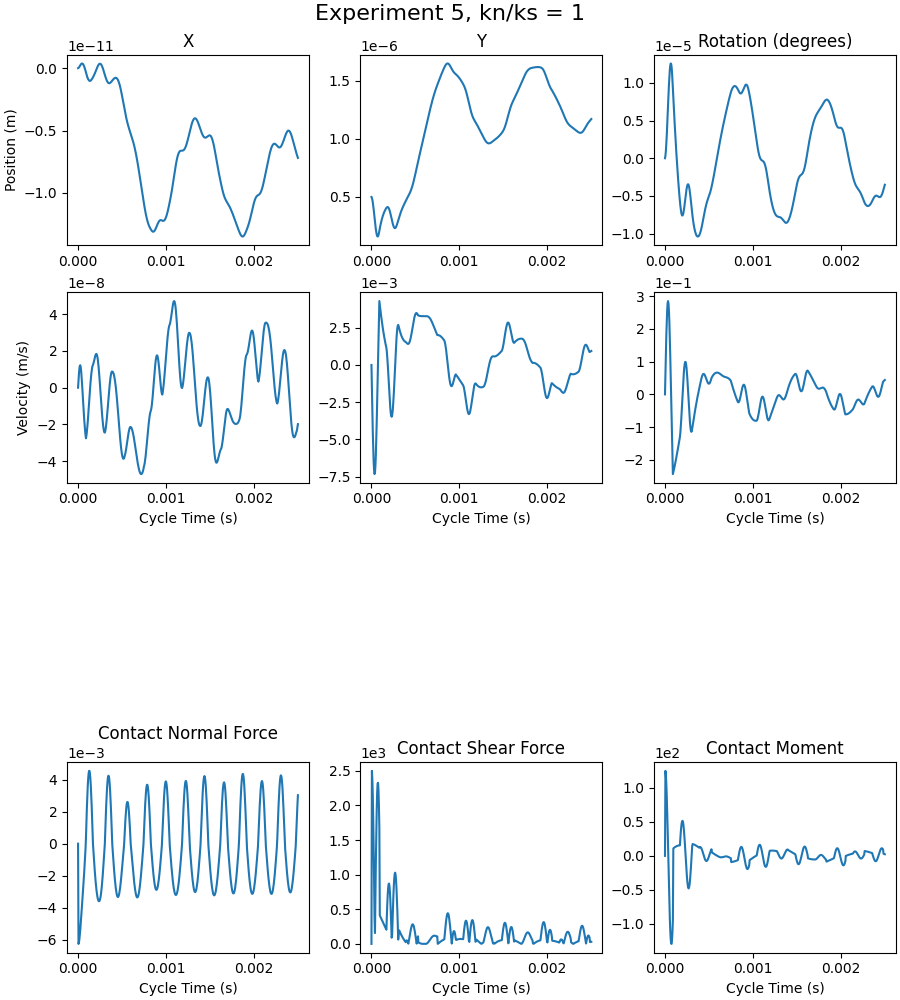

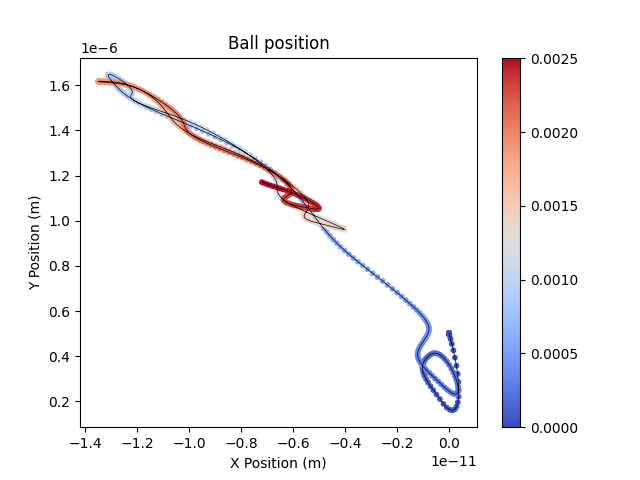

In [119]:
# Plot Physics Sim Data
cmp.bond_behavior_plots(df,experiment,kn_ks)

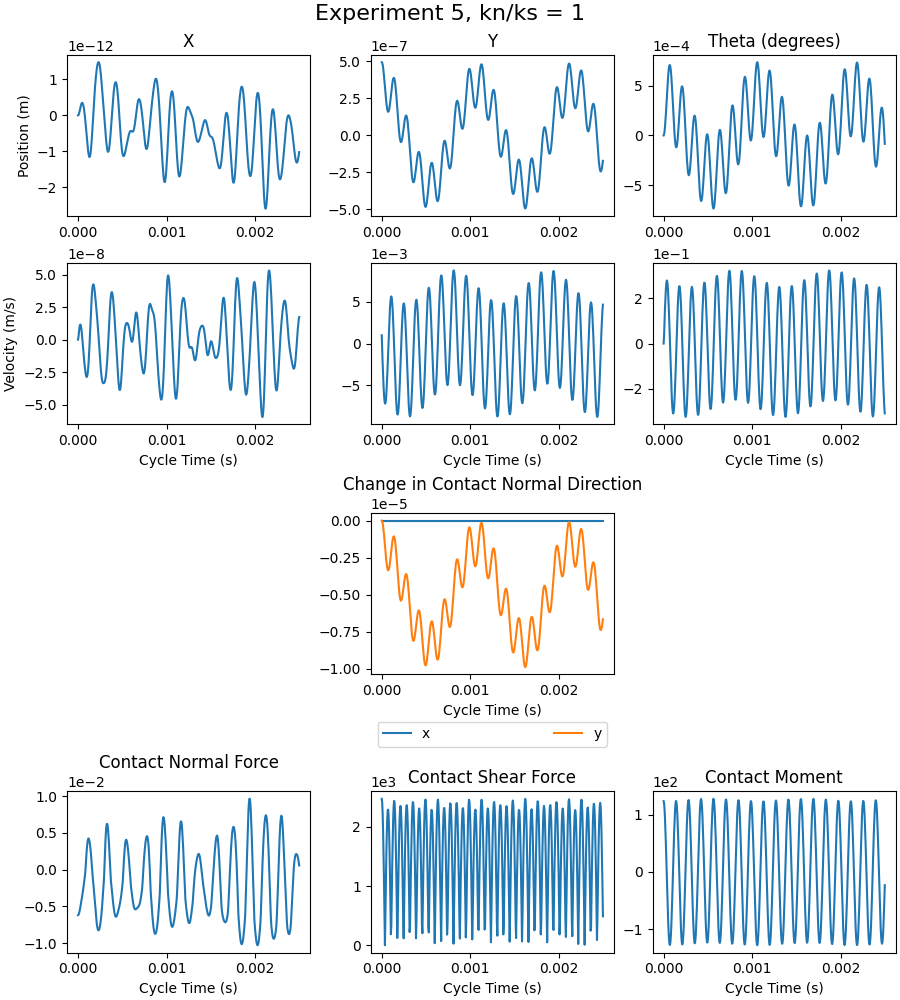

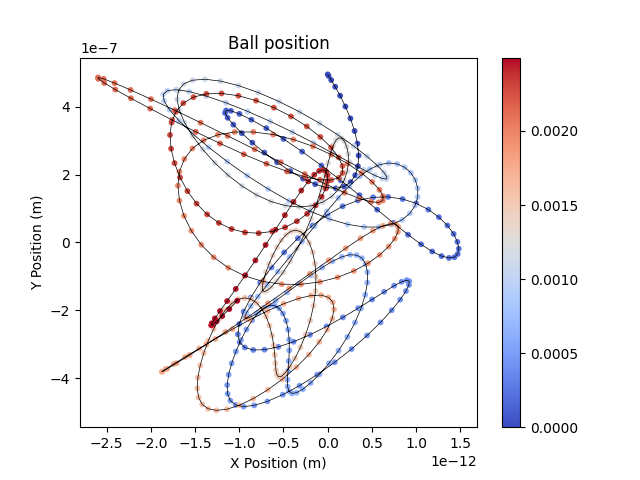

In [120]:
# Plot PFC Data
cmppfc.bond_behavior_plots(df2,experiment,kn_ks)


Text(0.5, 1.0, 'Ball position')

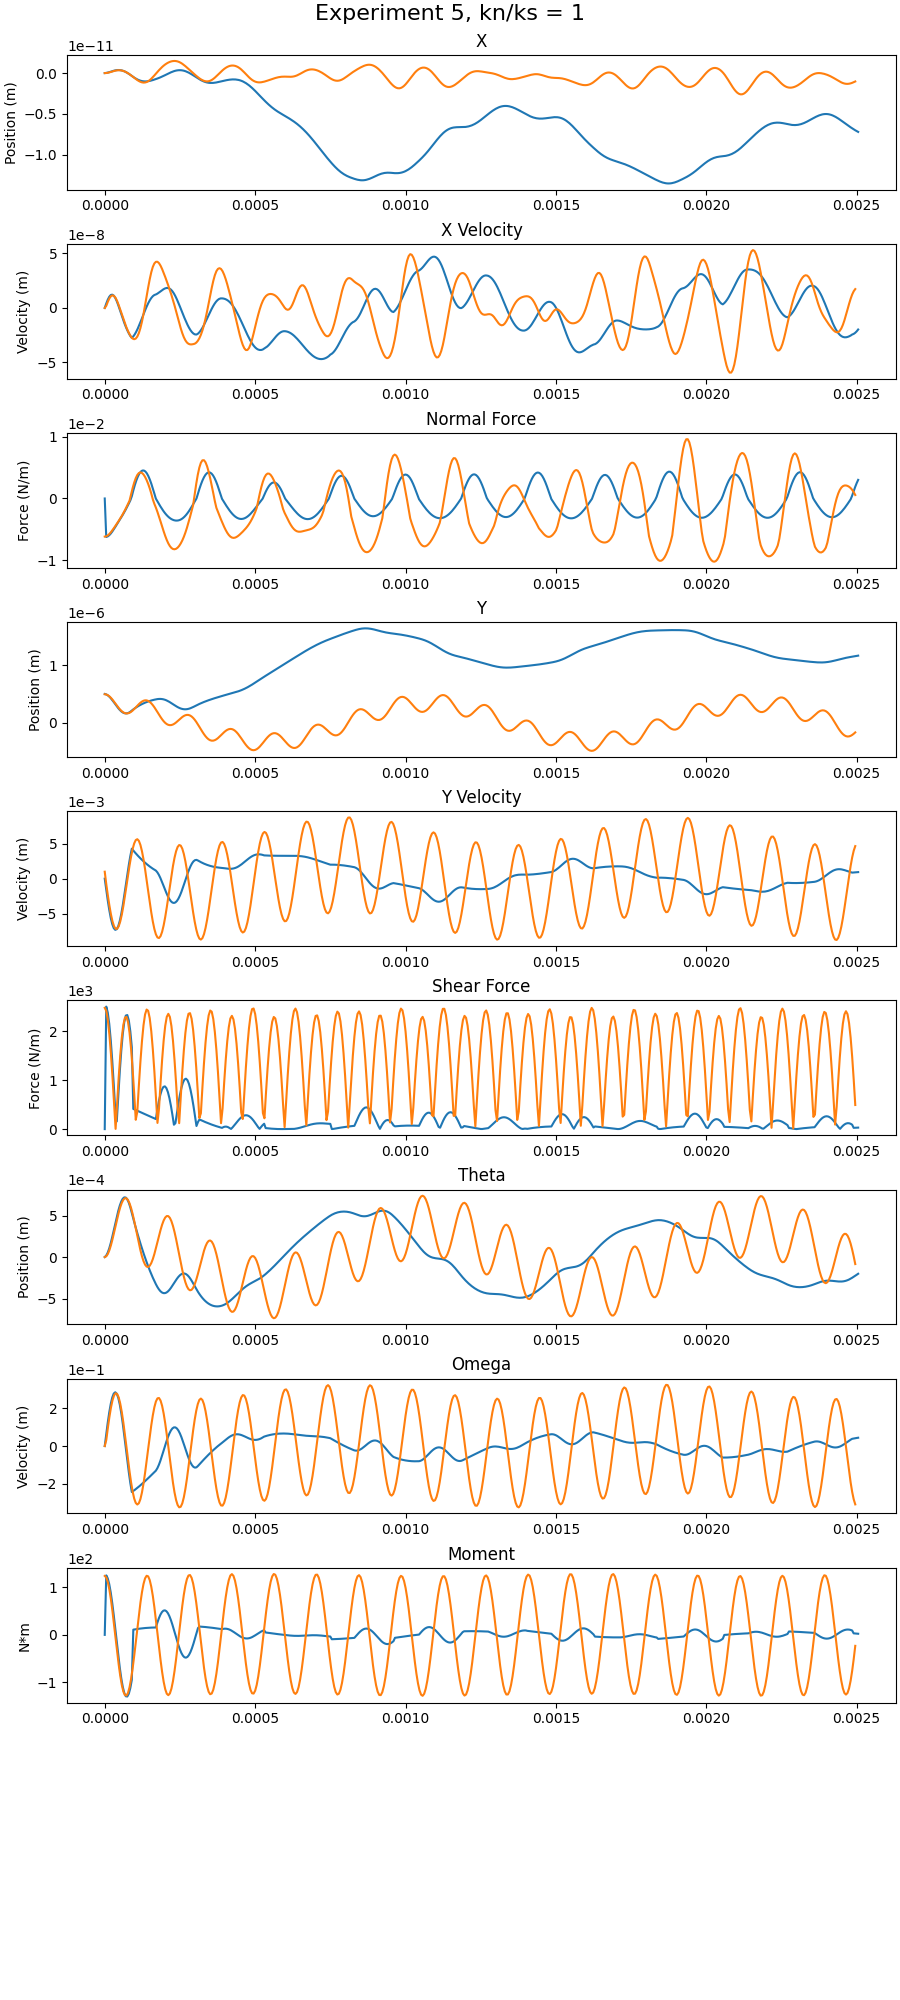

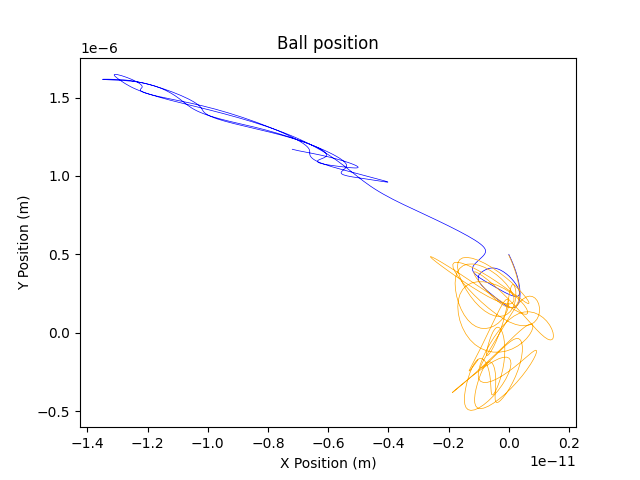

In [121]:
plt.close('all')
fig = plt.figure(figsize=(9,20), constrained_layout=True)
fig.suptitle(f'Experiment {experiment}, kn/ks = {kn_ks}', fontsize=16)
gs = fig.add_gridspec(11, 1)

# X Position
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_ylabel('Position (m)')
ax1.plot(df["Timestamp"], df["X Position"])
ax1.plot(df2["Time(s)"], df2["x_pos"])
ax1.set_title('X')

# X Velocity
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_ylabel('Velocity (m)')
ax2.plot(df["Timestamp"], df["X Velocity"])
ax2.plot(df2["Time(s)"], df2["x_vel"])
ax2.set_title('X Velocity')

# Normal Force
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_ylabel('Force (N/m)')
ax3.plot(df["Timestamp"], df["Data1"])
ax3.plot(df2["Time(s)"], df2["c_nforce"])
ax3.set_title('Normal Force')

# Y Position
ax4 = fig.add_subplot(gs[3, 0])
ax4.set_ylabel('Position (m)')
ax4.plot(df["Timestamp"], df["Y Position"])
ax4.plot(df2["Time(s)"], df2["y_pos"])
ax4.set_title('Y')

# Y Velocity
ax5 = fig.add_subplot(gs[4, 0])
ax5.set_ylabel('Velocity (m)')
ax5.plot(df["Timestamp"], df["Y Velocity"])
ax5.plot(df2["Time(s)"], df2["y_vel"])
ax5.set_title('Y Velocity')

# Shear Force
ax6 = fig.add_subplot(gs[5, 0])
ax6.set_ylabel('Force (N/m)')
ax6.plot(df["Timestamp"], df["Data2"].apply(abs))
ax6.plot(df2["Time(s)"], df2["c_sforce"])
ax6.set_title('Shear Force')

# Theta
ax7 = fig.add_subplot(gs[6, 0])
ax7.set_ylabel('Position (m)')
# ax7.plot(df["Timestamp"], df["Data1"])
ax7.plot(df["Timestamp"], df["Rotation"] * (180/3.14159))
ax7.plot(df2["Time(s)"], df2["theta"])
ax7.set_title('Theta')

# Omega
ax8 = fig.add_subplot(gs[7, 0])
ax8.set_ylabel('Velocity (m)')
# ax8.set_ylabel('Meters')
ax8.plot(df["Timestamp"], df["Rotation Velocity"])
# ax8.plot(df["Timestamp"], df["Data2"])
ax8.plot(df2["Time(s)"], df2["omega"])
ax8.set_title('Omega')
# ax8.set_title('Normal X')

# Moment
ax9 = fig.add_subplot(gs[8, 0])
ax9.set_ylabel('N*m')
ax9.plot(df["Timestamp"], df["Data3"])
ax9.plot(df2["Time(s)"], df2["c_moment"])
ax9.set_title('Moment')
# ax9.set_ylim(bottom=0.0316, top=0.03165)

# ax10 = fig.add_subplot(gs[9, 0])
# ax10.set_ylabel('Meters')
# ax10.plot(df["Timestamp"], df["Data4"])
# ax10.set_title('Normal Displacement')

# ax11 = fig.add_subplot(gs[10, 0])
# ax11.set_ylabel('FPS')
# ax11.plot(df["Timestamp"], df["FPS"])
# ax11.set_title('Performance')

ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax7.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax8.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax9.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# ax10.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# ax11.ticklabel_format(style='plain' ,axis='y', scilimits=(0,0))

fig2, ax = plt.subplots()
ax.plot(df["X Position"], df["Y Position"], linewidth=0.5, c='blue')
# pos = ax.scatter(df["X Position"], df["Y Position"], s=10, c=df["Timestamp"], cmap='warmcool')
# fig2.colorbar(pos, ax=ax)
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Ball position')

ax.plot(df2["x_pos"], df2["y_pos"], linewidth=0.5, c='orange')
# pos = ax.scatter(df2["x_pos"], df2["y_pos"], s=10, c=df2["Time(s)"], cmap='coolwarm')
# fig2.colorbar(pos, ax=ax)
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Ball position')